# Actividad 4.2 — Reentrenamiento CNN: Señales US para Webots

**Equipo:** Joel Arturo Becerril Balderas (A01797427)  
**Módulo:** Navegación Autónoma — Semana 7  

## Problema
El modelo GTSRB fue entrenado con señales **alemanas** (triángulos rojos, círculos rojos/azules).  
El mundo Webots usa señales **estadounidenses** (diamantes amarillos, rectángulos blancos, octágono rojo).  
Este notebook resuelve el **domain gap** entrenando un nuevo clasificador con:
1. Texturas exactas de Webots (descargadas del repositorio de Cyberbotics)
2. Augmentación pesada que simula perspectiva 3D, iluminación y renderizado sintético
3. Fine-tuning sobre el modelo GTSRB (reutiliza los filtros convolucionales aprendidos)

## Señales en el mundo Webots
| Clase | Nombre | Tipo en Webots |
|-------|--------|----------------|
| 14 | STOP | StopSign (octágono rojo) |
| 13 | Ceder paso | YieldSign (triángulo) |
| 18 | Precaución | CautionSign genérico |
| 19 | Curva izq. | CautionSign turn_left |
| 20 | Curva der. | CautionSign turn_right |
| 22 | Bache | CautionSign bump |
| 11 | Cruce | CautionSign cross_roads |
| 17 | Prohibido entrar | OrderSign no_right_turn |
| 15 | Sin vehículos | OrderSign no_pedestrian |
| 3  | Lím. 60 km/h | SpeedLimitSign 55 mph |
| 4  | Lím. 70 km/h | SpeedLimitSign 65 mph |
| 34 | Girar izquierda | one_way_sign_left |
| 35 | Solo adelante | HighwaySign |


## 1. Importaciones

In [1]:
import os, random, urllib.request, numpy as np
import cv2, matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

try:
    import seaborn as sns
    HAS_SNS = True
except ImportError:
    HAS_SNS = False
    print('[!] seaborn no instalado — matriz de confusión en modo básico')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.18.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuración de rutas y clases objetivo

In [ ]:
BASE_DIR    = Path(os.path.expanduser('~')) / 'MNA_WORKSPACE' / 'NAVEGACION_AUTONOMA' / 'Semana_7'
DATA_DIR    = BASE_DIR / 'webots_signs_raw'
AUG_DIR     = BASE_DIR / 'webots_signs_aug'
MODEL_IN    = BASE_DIR / 'modelo_gtsrb.keras'
MODEL_OUT   = BASE_DIR / 'modelo_us_webots.keras'

IMG_SIZE    = 32
AUG_PER_IMG = 200

WEBOTS_BASE = ('https://raw.githubusercontent.com/cyberbotics/webots/'
               'R2023b/projects/objects/traffic/protos/textures/signs')

SIGN_MAP = {
    14: ('STOP',         f'{WEBOTS_BASE}/stop.jpg'),              # era stop_sign.jpg (404)
    13: ('Ceder_paso',   f'{WEBOTS_BASE}/us/yield.jpg'),          # era yield_sign.jpg (404)
    19: ('Curva_izq',    f'{WEBOTS_BASE}/us/turn_left.jpg'),
    20: ('Curva_der',    f'{WEBOTS_BASE}/us/turn_right.jpg'),
    22: ('Bache',        f'{WEBOTS_BASE}/us/bump.jpg'),
    11: ('Cruce',        f'{WEBOTS_BASE}/us/cross_roads.jpg'),
    17: ('No_girar_der', f'{WEBOTS_BASE}/no_right_turn.jpg'),
    15: ('No_peatones',  f'{WEBOTS_BASE}/no_pedestrian_crossing.jpg'),
     3: ('Lim_60',       f'{WEBOTS_BASE}/us/speed_limit_55.jpg'),
     4: ('Lim_70',       f'{WEBOTS_BASE}/us/speed_limit_65.jpg'),
    34: ('Un_sentido',   f'{WEBOTS_BASE}/us/one_way_sign_left.jpg'),
}

TARGET_CLASSES = sorted(SIGN_MAP.keys())
print(f'Clases: {TARGET_CLASSES}  ({len(TARGET_CLASSES)} tipos)')

## 3. Descarga de texturas de Webots

In [3]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

descargadas, fallidas = [], []
for clase, (nombre, url) in SIGN_MAP.items():
    dest = DATA_DIR / f'{clase}_{nombre}.jpg'
    if dest.exists():
        print(f'  [OK] ya existe: {dest.name}')
        descargadas.append((clase, dest))
        continue
    try:
        urllib.request.urlretrieve(url, dest)
        print(f'  [↓]  {nombre}: {url.split("/")[-1]}')
        descargadas.append((clase, dest))
    except Exception as e:
        print(f'  [✗]  {nombre}: {e}')
        fallidas.append((clase, nombre, url))

print(f'\nDescargadas: {len(descargadas)}/{len(SIGN_MAP)}')
if fallidas:
    print('Fallidas (buscar manualmente):')
    for c, n, u in fallidas:
        print(f'  Clase {c} {n}: {u}')

  [✗]  STOP: HTTP Error 404: Not Found
  [✗]  Ceder_paso: HTTP Error 404: Not Found
  [✗]  Precaucion: HTTP Error 404: Not Found
  [OK] ya existe: 19_Curva_izq.jpg
  [OK] ya existe: 20_Curva_der.jpg
  [OK] ya existe: 22_Bache.jpg
  [OK] ya existe: 11_Cruce.jpg
  [OK] ya existe: 17_No_girar_der.jpg
  [OK] ya existe: 15_No_peatones.jpg
  [OK] ya existe: 3_Lim_60.jpg
  [OK] ya existe: 4_Lim_70.jpg
  [OK] ya existe: 34_Un_sentido.jpg
  [✗]  Adelante: HTTP Error 404: Not Found

Descargadas: 9/13
Fallidas (buscar manualmente):
  Clase 14 STOP: https://raw.githubusercontent.com/cyberbotics/webots/R2023b/projects/objects/traffic/protos/textures/signs/stop_sign.jpg
  Clase 13 Ceder_paso: https://raw.githubusercontent.com/cyberbotics/webots/R2023b/projects/objects/traffic/protos/textures/signs/yield_sign.jpg
  Clase 18 Precaucion: https://raw.githubusercontent.com/cyberbotics/webots/R2023b/projects/objects/traffic/protos/textures/signs/us/warning.jpg
  Clase 35 Adelante: https://raw.githubuserco

## 4. Augmentación sintética

Cada textura se transforma con:
- **Perspectiva aleatoria**: simula distintos ángulos de la cámara del carro
- **Escala variable**: señal cercana vs lejana
- **Brillo / contraste / saturación**: condiciones de iluminación Webots
- **Ruido gaussiano**: renderizado sintético introduce pequeñas imperfecciones
- **Rotación leve**: ±15°, postes no siempre están perfectamente verticales
- **Fondo sintético**: recorte sobre fondos grises/arena como en Webots

In [4]:
def augmentar_textura(img_bgr, n=200, size=32):
    """Genera n variantes augmentadas de una textura de señal."""
    h, w = img_bgr.shape[:2]
    resultados = []

    for _ in range(n):
        img = img_bgr.copy()

        # 1. Escala aleatoria (simula distancia)
        scale = random.uniform(0.5, 1.0)
        nh, nw = max(16, int(h * scale)), max(16, int(w * scale))
        img = cv2.resize(img, (nw, nh))

        # 2. Perspectiva aleatoria
        ph, pw = img.shape[:2]
        max_skew = int(min(ph, pw) * 0.15)
        src = np.float32([[0, 0], [pw, 0], [pw, ph], [0, ph]])
        dst = np.float32([
            [random.randint(0, max_skew), random.randint(0, max_skew)],
            [pw - random.randint(0, max_skew), random.randint(0, max_skew)],
            [pw - random.randint(0, max_skew), ph - random.randint(0, max_skew)],
            [random.randint(0, max_skew), ph - random.randint(0, max_skew)],
        ])
        M = cv2.getPerspectiveTransform(src, dst)
        img = cv2.warpPerspective(img, M, (pw, ph),
                                  borderMode=cv2.BORDER_REPLICATE)

        # 3. Rotación leve
        angle = random.uniform(-15, 15)
        ch, cw = img.shape[:2]
        R = cv2.getRotationMatrix2D((cw // 2, ch // 2), angle, 1.0)
        img = cv2.warpAffine(img, R, (cw, ch),
                             borderMode=cv2.BORDER_REPLICATE)

        # 4. Brillo y contraste
        alpha = random.uniform(0.6, 1.4)   # contraste
        beta  = random.uniform(-40, 40)    # brillo
        img = np.clip(img.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

        # 5. Saturación (HSV)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * random.uniform(0.5, 1.5), 0, 255)
        img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

        # 6. Ruido gaussiano
        noise = np.random.normal(0, random.uniform(0, 12), img.shape).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        # 7. Fondo sintético estilo Webots (gris arena)
        bg_color = [random.randint(140, 200)] * 3
        canvas = np.full((size, size, 3), bg_color, dtype=np.uint8)
        # Centrar la señal en el canvas
        ih, iw = img.shape[:2]
        sw = min(iw, size - 2)
        sh = min(ih, size - 2)
        img_small = cv2.resize(img, (sw, sh))
        x0 = (size - sw) // 2
        y0 = (size - sh) // 2
        canvas[y0:y0+sh, x0:x0+sw] = img_small

        resultados.append(canvas)

    return resultados

In [5]:
AUG_DIR.mkdir(parents=True, exist_ok=True)

for clase, path in descargadas:
    nombre = SIGN_MAP[clase][0]
    out_dir = AUG_DIR / f'{clase}_{nombre}'
    out_dir.mkdir(exist_ok=True)

    img = cv2.imread(str(path))
    if img is None:
        print(f'[!] No se puede leer: {path}')
        continue

    variantes = augmentar_textura(img, n=AUG_PER_IMG, size=IMG_SIZE)
    for i, v in enumerate(variantes):
        cv2.imwrite(str(out_dir / f'aug_{i:04d}.png'), v)

    print(f'  [{clase:2d}] {nombre}: {len(variantes)} imágenes')

print('\nAugmentación completa')

  [19] Curva_izq: 200 imágenes
  [20] Curva_der: 200 imágenes
  [22] Bache: 200 imágenes
  [11] Cruce: 200 imágenes
  [17] No_girar_der: 200 imágenes
  [15] No_peatones: 200 imágenes
  [ 3] Lim_60: 200 imágenes
  [ 4] Lim_70: 200 imágenes
  [34] Un_sentido: 200 imágenes

Augmentación completa


## 5. Visualización de muestras augmentadas

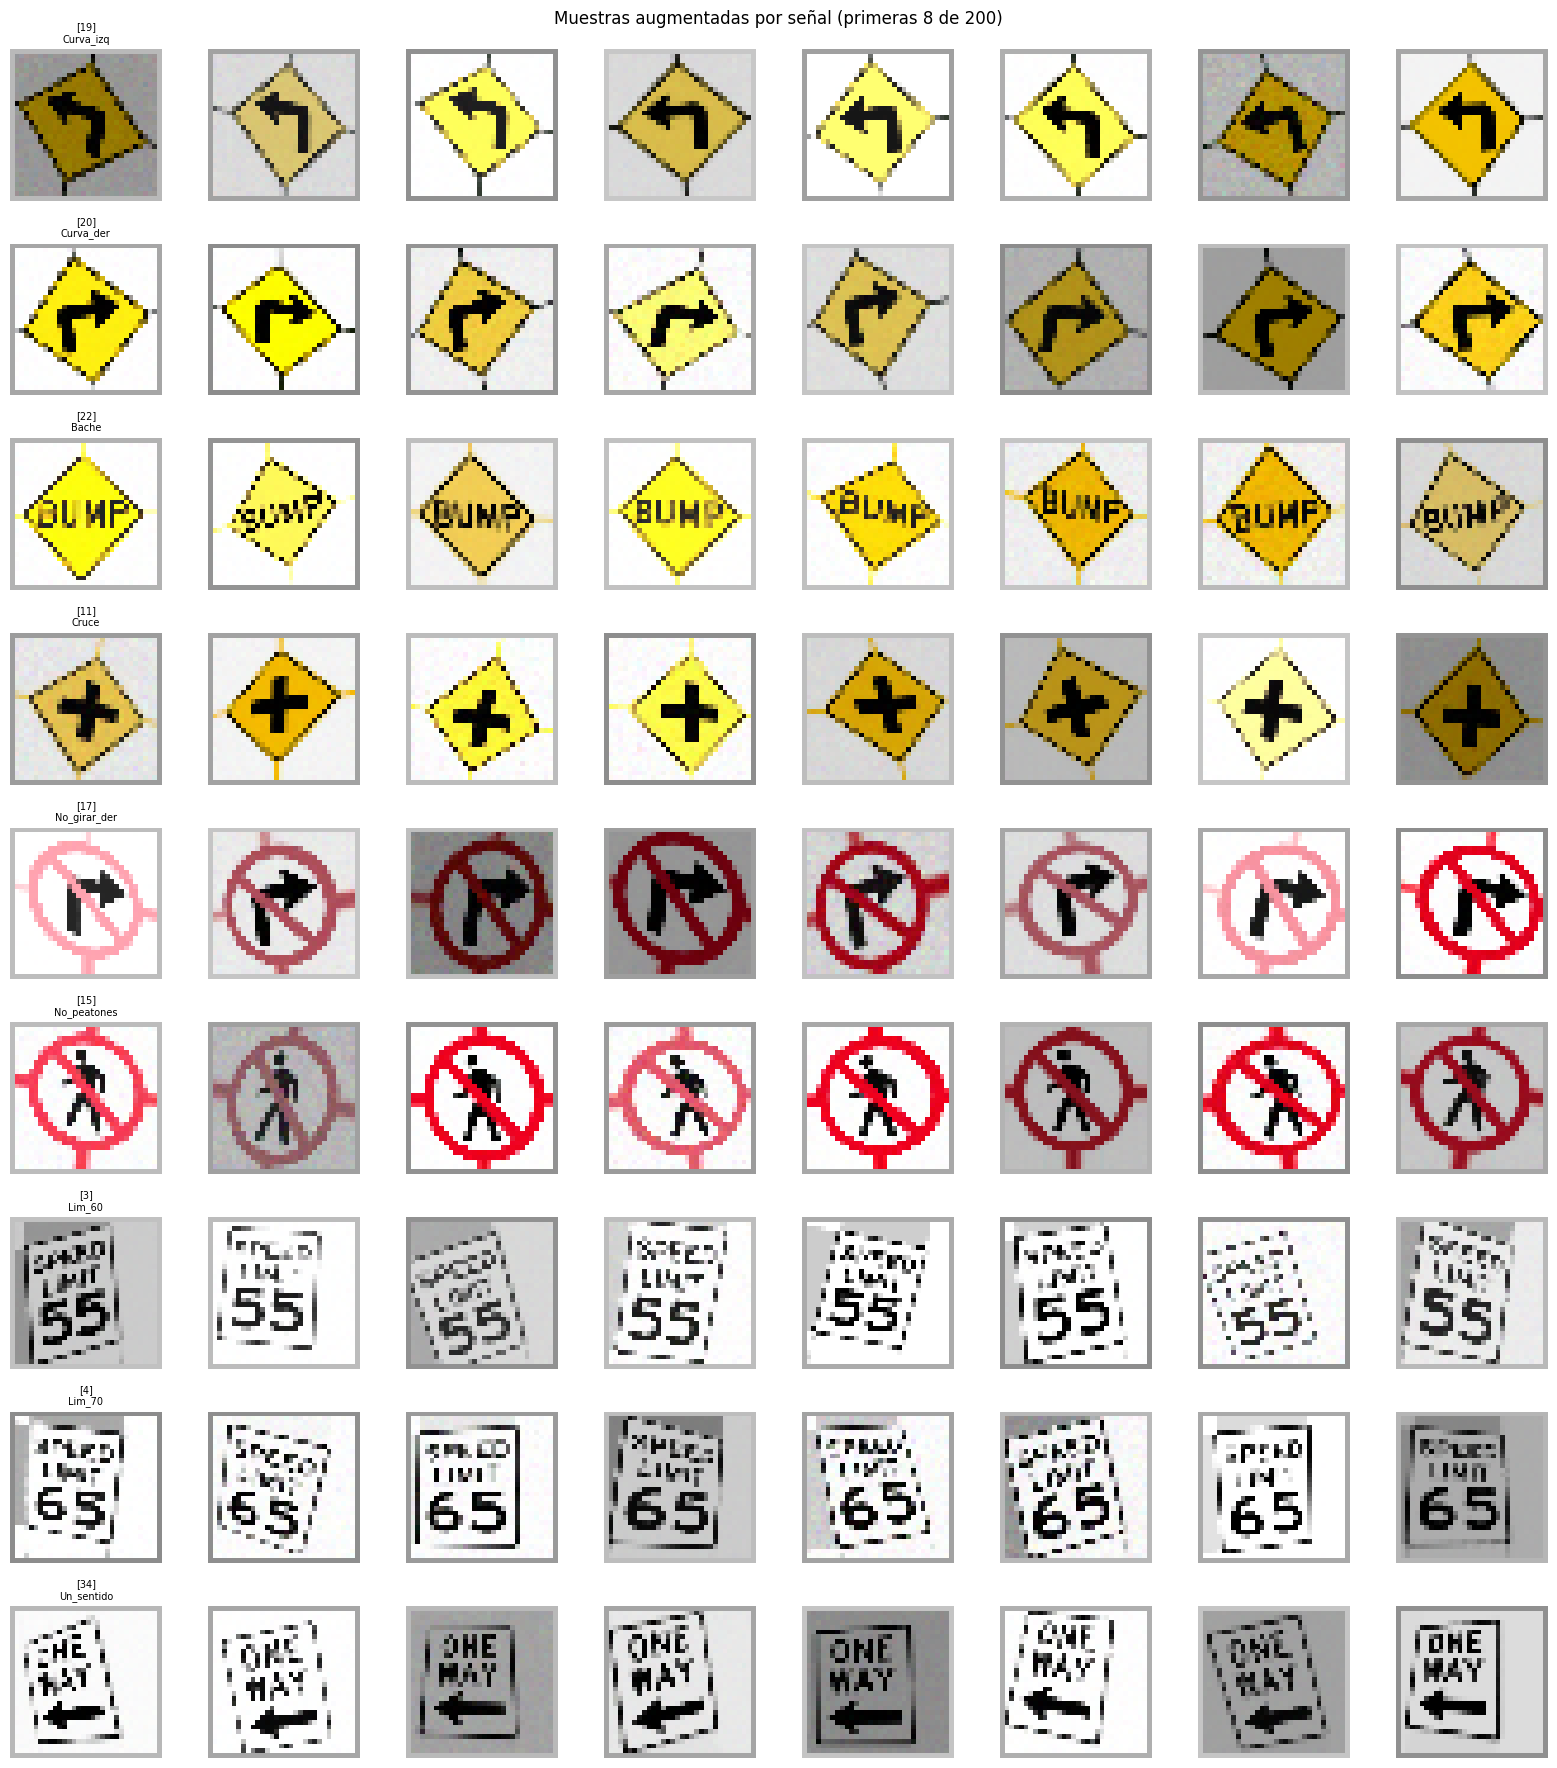

In [6]:
fig, axes = plt.subplots(len(descargadas), 8, figsize=(16, len(descargadas) * 2))
if len(descargadas) == 1:
    axes = [axes]

for row, (clase, _) in enumerate(descargadas):
    nombre = SIGN_MAP[clase][0]
    out_dir = AUG_DIR / f'{clase}_{nombre}'
    imgs = sorted(out_dir.glob('*.png'))[:8]
    for col, img_path in enumerate(imgs):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(f'[{clase}]\n{nombre}', fontsize=7)

plt.suptitle('Muestras augmentadas por señal (primeras 8 de 200)')
plt.tight_layout()
plt.show()

## 6. Carga del dataset augmentado

In [7]:
X_all, y_all = [], []

for clase, (nombre, _) in SIGN_MAP.items():
    out_dir = AUG_DIR / f'{clase}_{nombre}'
    if not out_dir.exists():
        continue
    for img_path in out_dir.glob('*.png'):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X_all.append(img.astype(np.float32) / 255.0)
        y_all.append(clase)

X_all = np.array(X_all)
y_all = np.array(y_all, dtype=np.int64)

# Remap a índices 0..N-1 para el modelo
UNIQUE_CLASSES = sorted(set(y_all))
CLASS_TO_IDX   = {c: i for i, c in enumerate(UNIQUE_CLASSES)}
IDX_TO_CLASS   = {i: c for c, i in CLASS_TO_IDX.items()}
y_idx = np.array([CLASS_TO_IDX[c] for c in y_all], dtype=np.int64)

print(f'Dataset: {X_all.shape}  |  Clases: {len(UNIQUE_CLASSES)}')
for c in UNIQUE_CLASSES:
    n = (y_all == c).sum()
    print(f'  [{c:2d}] {SIGN_MAP[c][0]:20s}: {n} imgs')

X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_idx, test_size=0.20, random_state=SEED, stratify=y_idx
)
print(f'Train: {X_tr.shape}  |  Val: {X_val.shape}')

Dataset: (1800, 32, 32, 3)  |  Clases: 9
  [ 3] Lim_60              : 200 imgs
  [ 4] Lim_70              : 200 imgs
  [11] Cruce               : 200 imgs
  [15] No_peatones         : 200 imgs
  [17] No_girar_der        : 200 imgs
  [19] Curva_izq           : 200 imgs
  [20] Curva_der           : 200 imgs
  [22] Bache               : 200 imgs
  [34] Un_sentido          : 200 imgs
Train: (1440, 32, 32, 3)  |  Val: (360, 32, 32, 3)


## 7. Fine-tuning del modelo GTSRB

**Estrategia Transfer Learning:**
- Las capas convolucionales (bloques 1-3) ya aprendieron detectar bordes, formas y colores → **se congelan**
- Solo se reentrena el clasificador Dense + la capa de salida (ajustada al número de clases US)
- Learning rate bajo (1e-4) para no destruir los pesos aprendidos


In [ ]:
NUM_CLASSES_US = len(UNIQUE_CLASSES)

base = load_model(str(MODEL_IN))

inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_us')
x = inp

for i, layer in enumerate(base.layers):
    if i == 0:
        continue
    if type(layer).__name__ == 'Flatten':
        break
    layer.trainable = False
    x = layer(x)

x   = keras.layers.Flatten(name='head_flatten')(x)
x   = keras.layers.Dense(256, activation='relu', name='head_dense')(x)
x   = keras.layers.BatchNormalization(name='head_bn')(x)
x   = keras.layers.Dropout(0.5, name='head_dropout')(x)
out = keras.layers.Dense(NUM_CLASSES_US, activation='softmax', name='head_output')(x)

model_us = keras.Model(inputs=inp, outputs=out)

trainable = sum(np.prod(v.shape) for v in model_us.trainable_variables)
total     = sum(np.prod(v.shape) for v in model_us.variables)
print(f'Params entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')
model_us.summary()

In [ ]:
model_us.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                   restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=3, min_lr=1e-6, verbose=1)
]

history = model_us.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

: 

: 

: 

## 8. Curvas de entrenamiento

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Época')
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Época')
plt.tight_layout(); plt.show()

vl, va = model_us.evaluate(X_val, y_val, verbose=0)
print(f'Val Loss: {vl:.4f}  |  Val Accuracy: {va:.4f}')

: 

: 

: 

## 9. Evaluación y matriz de confusión

In [ ]:
y_pred = np.argmax(model_us.predict(X_val), axis=1)
nombres = [SIGN_MAP[IDX_TO_CLASS[i]][0] for i in range(NUM_CLASSES_US)]

print(classification_report(y_val, y_pred, target_names=nombres))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres, yticklabels=nombres)
plt.title('Matriz de Confusión — Señales US')
plt.xlabel('Predicción'); plt.ylabel('Real')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

: 

: 

: 

## 10. Guardar modelo y mapeo de clases

In [ ]:
model_us.save(str(MODEL_OUT))
print(f'Modelo guardado: {MODEL_OUT}')

# Guardar el mapeo índice→clase GTSRB para usarlo en el controlador
import json
mapeo = {str(i): int(c) for i, c in IDX_TO_CLASS.items()}
mapeo_path = BASE_DIR / 'us_class_map.json'
with open(mapeo_path, 'w') as f:
    json.dump(mapeo, f, indent=2)
print(f'Mapeo guardado: {mapeo_path}')
print(json.dumps(mapeo, indent=2))

: 

: 

: 

## 11. Actualizar el controlador de Webots

Copia esto en `simple_controller_H2_CNN.py`:

```python
import json

MODEL_PATH   = os.path.join(os.path.dirname(__file__), '..', 'modelo_us_webots.keras')
MAP_PATH     = os.path.join(os.path.dirname(__file__), '..', 'us_class_map.json')

# Al cargar el modelo:
with open(MAP_PATH) as f:
    IDX_TO_GTSRB = {int(k): int(v) for k, v in json.load(f).items()}

# En clasificar(): cambiar la última línea a:
cid_local = int(np.argmax(probs))
cid = IDX_TO_GTSRB[cid_local]   # convertir a clase GTSRB
return cid, float(probs[cid_local])
```
